In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os
import numpy as np
import seaborn as sns
import numpy as np
from scipy.stats import rankdata, friedmanchisquare, f

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
CLF_METRICS = ["kappa"] #, "precision", "recall", "f1-score"]
CLF_MODELS = ["RandomForestClassifier", "DecisionTreeClassifier"] #, "DecisionTreeClassifier", "LogisticRegression", "SVC"]

REG_METRICS = ["r2"] # , "mse", "std"]
REG_MODELS = ["RandomForestRegressor"] #, "DecisionTreeRegressor"]

DATASETS = [file for file in os.listdir("../../datasets/synthetic/") if "csv" in file]
REG_DATASETS = ["gradual_friedman.csv"]
CLF_DATASETS = list(set(DATASETS).difference(set(REG_DATASETS)))

In [3]:
def get_concept(original_idx: pd.Series, dataset: str, concept_type="last"):
    """Read the original dataframe to recover the context

    Args:
        original_idx (pd.Series): maps the metabase indexes to the original base indexes (before windowing)
        dataset (str): dataset name to be loaded
        concept_type (str, optional): how to set the window concept, it can be:
            - "last": The last concept of the batch
            - "most_frequent": The most frequent concept of the batch
    """
    filename_concept = f'../../datasets/synthetic/{dataset}'
    df_concept = pd.read_csv(filename_concept)['concept']

    concepts = []
    for idx in original_idx:
        bounds = [int(bound) for bound in idx.split(':')]
        concept_batch = df_concept[bounds[0]:bounds[1]]
        
        if concept_type == "last":
            concepts.append(concept_batch.values[-1])
        else:
            most_frequent_concept = concept_batch.value_counts().idxmax()
            concepts.append(most_frequent_concept)
    return concepts

def load_data(dataset, model, concept_type="last"):
    filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
    results = pd.read_csv(filename_mtl)
    concept = get_concept(results['original_idx'], dataset, concept_type)
    results['concept'] = concept
    return results

In [4]:
def remove_unused_cols(df: pd.DataFrame) -> pd.DataFrame:
    metrics = CLF_METRICS if "kappa" in df.columns else REG_METRICS
    cols_to_keep = [
        "concept",  # concept
        *metrics,  # target cols
        *[f"last_{col}" for col in metrics],  # baseline cols
        *[col for col in df.columns if "drift" in col],  # drift metrics cols
        *[col for col in df.columns if "predicted" in col],  # mtl cols
    ]
    return df[cols_to_keep]

def gen_drift_alerts(dataset: str, model: str, metric: str) -> pd.DataFrame:
    df = load_data(dataset, model)
    offline_df = df[df["data_type"] == "offline"]
    online_df = df[df["data_type"] == "online"]
    online_df = remove_unused_cols(online_df)

    expected_mean, expected_std = offline_df[metric].mean(), offline_df[metric].std()

    for sensitivity in [0.5, 1, 1.5, 2]:
        threshold = expected_mean - expected_std * sensitivity
        online_df[f"mtl_alert_{metric}_s={sensitivity}"] = (online_df[f"predicted_{metric}"] <= threshold).astype(int)
    online_df["target_alert"] = (online_df["concept"] > 0).astype(int)
    # online_df["real_alert"] = (online_df[metric] <= threshold).astype(int)
    return online_df

In [5]:
results = {}

for dataset in DATASETS:
    try:
        metric = "kappa" if dataset in CLF_DATASETS else "r2"
        model = "DecisionTreeClassifier" if dataset in CLF_DATASETS else "DecisionTreeClassifier"
        results[dataset] = gen_drift_alerts(dataset, model, metric)
    except:
        print(dataset)

gradual_friedman.csv


# Drift label comparison

In [6]:
def get_perf_metrics(df: pd.DataFrame, dataset: str, target_col="target_alert") -> list:
    alert_cols = [c for c in df.columns if ("_drift_" in c or "_alert" in c)]
    results = []

    for col in alert_cols:
        sensitivity = col.split("s=")[1] if "s=" in col else None
        alert_type = "drift_metrics" if "_drift_" in col else col.split("_")[0]

        # Generate confusion matrix
        cm = confusion_matrix(df[target_col], df[col], labels = [0, 1]).ravel()
        results.append({
            'dataset': dataset.replace('.csv', ''),
            'alert_col': col,
            'type': alert_type,
            'sensitivity': sensitivity,
            'True Negatives': cm[0], 
            'False Positives': cm[1], 
            'False Negatives': cm[2], 
            'True Positives': cm[3],
            'accuracy': accuracy_score(df[target_col], df[col]),
            **classification_report(df[target_col], df[col], labels = [0, 1], output_dict=True)['1']
        })
    return results

final_performances = []
for dataset, df in results.items():
    df = results[dataset]
    final_performances = [*final_performances, *get_perf_metrics(df, dataset)]
final_performances_df = pd.DataFrame(final_performances)

In [7]:
#final_performances_df[final_performances_df["dataset"]=="gradual_agrawal_unbalanced_with_noise"]
final_performances_df.head(10)

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
0,abrupt_stagger_balanced,psi_drift_flag,drift_metrics,None,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
1,abrupt_stagger_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,272,1,0.510791,1.000000,0.003663,0.007299,273.0
2,abrupt_stagger_balanced,u_detect_drift_flag,drift_metrics,None,224,59,193,80,0.546763,0.575540,0.293040,0.388350,273.0
3,abrupt_stagger_balanced,sqsi_drift_flag,drift_metrics,None,235,48,0,273,0.913669,0.850467,1.000000,0.919192,273.0
4,abrupt_stagger_balanced,dc_drift_flag,drift_metrics,None,2,281,16,257,0.465827,0.477695,0.941392,0.633785,273.0
5,abrupt_stagger_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
6,abrupt_stagger_balanced,mtl_alert_kappa_s=1,mtl,1,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
7,abrupt_stagger_balanced,mtl_alert_kappa_s=1.5,mtl,1.5,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
8,abrupt_stagger_balanced,mtl_alert_kappa_s=2,mtl,2,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
9,abrupt_stagger_balanced,target_alert,target,None,283,0,0,273,1.000000,1.000000,1.000000,1.000000,273.0


# DataFrame formating

## Functions & dictionaries

In [8]:
# Renomeando nomes dos datasets para diminuir o tamanho e ficar alinhado com o artigo do BRACIS1'26
dataset_rename = {
    "gradual_agrawal_balanced_with_noise": "P1",
    "gradual_agrawal_balanced": "P2",
    "gradual_agrawal_unbalanced_with_noise": "P3",
    "gradual_agrawal_unbalanced": "P4",
    "abrupt_recurring_mixed_balanced": "P5",
    "abrupt_mixed_balanced": "P6",
    "abrupt_mixed_unbalanced": "P7",
    "abrupt_recurring_sea": "P8",
    "abrupt_sea_noise": "P9",
    "abrupt_sea": "P10",
    "abrupt_recurring_sine_balanced": "P11",
    "abrupt_sine_unbalanced": "P12",
    "abrupt_sine_unbalanced_noise": "P13",
    "abrupt_sine_balanced": "P14",
    "abrupt_sine_balanced_noise": "P15",
    "abrupt_recurring_stagger_balanced": "P16",
    "abrupt_stagger_balanced": "P17",
    "abrupt_stagger_unbalanced": "P18",
}
    
# Renomeando nomes dos 'drift alerts' para diminuir o tamanho e ficar alinhado com o artigo do BRACIS1'26
alert_col_rename = {
    'psi_drift_flag': 'psi',
    'u_detect_drift_flag': 'udetect',
    'sqsi_drift_flag': 'sqsi',
    'dc_drift_flag': 'dc',
    'mtl_alert_kappa_s=0.5': 'MetaDD (s=0.5)',
    'mtl_alert_kappa_s=1': 'MetaDD (s=1.0)',
    'mtl_alert_kappa_s=2': 'MetaDD (s=2.0)',
}

In [9]:
friedman_test_cols = list(alert_col_rename.keys())
friedman_test_cols

['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

In [10]:
friedman_test_rows = list(dataset_rename.keys())
friedman_test_rows

['gradual_agrawal_balanced_with_noise',
 'gradual_agrawal_balanced',
 'gradual_agrawal_unbalanced_with_noise',
 'gradual_agrawal_unbalanced',
 'abrupt_recurring_mixed_balanced',
 'abrupt_mixed_balanced',
 'abrupt_mixed_unbalanced',
 'abrupt_recurring_sea',
 'abrupt_sea_noise',
 'abrupt_sea',
 'abrupt_recurring_sine_balanced',
 'abrupt_sine_unbalanced',
 'abrupt_sine_unbalanced_noise',
 'abrupt_sine_balanced',
 'abrupt_sine_balanced_noise',
 'abrupt_recurring_stagger_balanced',
 'abrupt_stagger_balanced',
 'abrupt_stagger_unbalanced']

In [11]:
# Filtra e renomeia algumas colunas do DataFrame para exibição em diagramas (e.g., heatmap).
def col_filter(raw_df: pd.DataFrame):
    # Filtrando valores que não são de interesse para o artigo do BRACIS'26
    df = raw_df[raw_df["dataset"] != "gradual_friedman"]
    df = df[~df["alert_col"].isin(["target_alert", "mtl_alert_kappa_s=1.5", "omv_pth_drift_flag"])]
    df = df[~df["dataset"].isin(["gradual_agrawal_balanced_increasing_noise", "gradual_agrawal_unbalanced_increasing_noise"])]
    return df

In [12]:
filtered = col_filter(final_performances_df)
filtered

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
0,abrupt_stagger_balanced,psi_drift_flag,drift_metrics,None,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
2,abrupt_stagger_balanced,u_detect_drift_flag,drift_metrics,None,224,59,193,80,0.546763,0.575540,0.293040,0.388350,273.0
3,abrupt_stagger_balanced,sqsi_drift_flag,drift_metrics,None,235,48,0,273,0.913669,0.850467,1.000000,0.919192,273.0
4,abrupt_stagger_balanced,dc_drift_flag,drift_metrics,None,2,281,16,257,0.465827,0.477695,0.941392,0.633785,273.0
5,abrupt_stagger_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,abrupt_sine_balanced_noise,sqsi_drift_flag,drift_metrics,None,283,0,440,0,0.391425,0.000000,0.000000,0.000000,440.0
194,abrupt_sine_balanced_noise,dc_drift_flag,drift_metrics,None,0,283,0,440,0.608575,0.608575,1.000000,0.756664,440.0
195,abrupt_sine_balanced_noise,mtl_alert_kappa_s=0.5,mtl,0.5,192,91,0,440,0.874136,0.828625,1.000000,0.906282,440.0
196,abrupt_sine_balanced_noise,mtl_alert_kappa_s=1,mtl,1,224,59,0,440,0.918396,0.881764,1.000000,0.937167,440.0


## Dataframe exploration

In [13]:
friedman_test_rows = final_performances_df["dataset"].unique().tolist()

# Remove valores que não foram considerados no artigo para o BRACIS
friedman_test_rows.remove('gradual_agrawal_balanced_increasing_noise')
friedman_test_rows.remove('gradual_agrawal_unbalanced_increasing_noise')

print("Total de detectores:", len(friedman_test_rows))
friedman_test_rows

Total de detectores: 18


['abrupt_stagger_balanced',
 'gradual_agrawal_balanced',
 'abrupt_recurring_mixed_balanced',
 'abrupt_recurring_sea',
 'gradual_agrawal_unbalanced_with_noise',
 'abrupt_recurring_sine_balanced',
 'abrupt_recurring_stagger_balanced',
 'abrupt_sea_noise',
 'abrupt_stagger_unbalanced',
 'abrupt_sine_unbalanced',
 'abrupt_sine_unbalanced_noise',
 'abrupt_mixed_balanced',
 'abrupt_sine_balanced',
 'abrupt_mixed_unbalanced',
 'gradual_agrawal_balanced_with_noise',
 'abrupt_sea',
 'gradual_agrawal_unbalanced',
 'abrupt_sine_balanced_noise']

In [14]:
friedman_test_cols = final_performances_df["alert_col"].unique().tolist()

# Remove valores que não foram considerados no artigo para o BRACIS
friedman_test_cols.remove('mtl_alert_kappa_s=1.5')
friedman_test_cols.remove('omv_pth_drift_flag')
friedman_test_cols.remove('target_alert')

print("Total de detectores:", len(friedman_test_cols))
friedman_test_cols

Total de detectores: 7


['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

# Display functions

In [15]:
def heatmap(df: pd.DataFrame, cell_width=0.8, cell_height=0.4):
    n_cols = df.shape[1]
    n_rows = df.shape[0]

    fig, ax = plt.subplots(figsize=(n_cols * cell_width, n_rows * cell_height))

    sns.heatmap(
        df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.6, 'label': 'F1-score', 'pad': 0.05},
        ax=ax,
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_xlabel('Type of Drifts', fontsize=10)
    ax.set_ylabel('Drift Detection Methods', fontsize=10)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_heatmap(df: pd.DataFrame, metric='f1-score', metric_label=None):
    # Pivot: datasets nas colunas (eixo X), alert_col nas linhas (eixo Y)
    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)

    fig, ax = plt.subplots(figsize=(12, 2.5))

    if metric_label == None:
        metric_label=metric
    
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        cbar=True,
        cbar_kws={'shrink': 0.6, 'label': metric_label, 'pad':0.01},
        ax=ax,
    )

    # Eixo X: datasets rotacionados verticalmente (como na imagem)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha='center',
        fontsize=8,
    )

    # Eixo Y: alert_col na horizontal, à direita (como na imagem)
    ax.yaxis.set_label_position('left')
    ax.yaxis.tick_left()
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=8,
    )

    ax.set_xlabel('Problem Space', fontsize=10)
    ax.set_ylabel('Drift Detection Methods', fontsize=10)
    #ax.set_title(f'{metric} heatmap', fontsize=11)

    plt.tight_layout()
    plt.show()

In [17]:
def plot_heatmap_grouped(df: pd.DataFrame, metric='f1-score', metric_label=None, groups=None):
    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)

    # Ordena colunas
    ordered_cols = sorted(pivot_df.columns, key=lambda x: int(x[1:]))
    pivot_df = pivot_df[ordered_cols]

    # TODO: Remover esse trecho para adicionar uma exceção caso o grupo não seja informado.
    # Define os grupos
    if groups == None:
        groups = {
            "Gradual":               ["P1", "P2", "P3", "P4"],
            "Abrupt":                ["P6", "P7", "P9", "P10", "P12", "P13", "P14", "P15", "P17", "P18"],
            "Abrupt and Recurring":  ["P5", "P8", "P11", "P16"],
        }

    n_groups = len(groups)
    group_sizes = [len(v) for v in groups.values()]

    fig, axes = plt.subplots(
        1, n_groups,
        figsize=(sum(group_sizes) * .6, len(pivot_df) * 0.4),
        gridspec_kw={"width_ratios": group_sizes}  # largura proporcional ao nº de colunas
    )

    if metric_label == None:
        metric_label = metric
    
    for ax, (group_name, cols) in zip(axes, groups.items()):
        subset = pivot_df[cols]
        is_last = (group_name == list(groups.keys())[-1])

        sns.heatmap(
            subset,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 8},
            cbar=is_last,  # barra de cores só no último grupo
            cbar_kws={'shrink': 0.6, 'label': metric_label} if is_last else {},
            yticklabels=True,  # mostra alert_col em todos
            ax=ax,
            vmin=pivot_df.min().min(),  # escala de cores uniforme entre grupos
            vmax=pivot_df.max().max(),
        )

        ax.set_title(group_name, fontsize=10)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

        # Eixo Y só no primeiro grupo
        if ax != axes[0]:
            ax.set_ylabel('')
            ax.yaxis.set_visible(False)  # remove ticks, labels e o "-" de uma vez
            #ax.set_yticklabels([])
        else:
            ax.set_ylabel('Drift Detection Methods', fontsize=10)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    #fig.suptitle(f'{metric} heatmap', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Rótulo "Problem Space" centralizado no eixo X da figura inteira
    fig.text(0.5, -0.02, 'Problem Space', ha='center', fontsize=10)
    
    plt.show()

# Friedman & Nemenyi analysis

In [18]:
from scipy.stats import friedmanchisquare

def friedman_test(df: pd.DataFrame, alpha=0.05, verbose=False):
    # Cada coluna é um tratamento (grupo), cada linha é um bloco (método)
    stat, p_value = friedmanchisquare(*[df[col].values for col in df.columns])

    if verbose:
        print(f"Friedman Test")
        print(f"  Statistic : {stat:.4f}")
        print(f"  p-value   : {p_value:.4f}")
        print(f"  alpha     : {alpha}")
        print()
    
        if p_value < alpha:
            print("✅ Rejeita H0: há diferença significativa entre os métodos.")
            return True
        else:
            print("❌ Falha em rejeitar H0: não há diferença significativa entre os métodos.")
            return False

In [19]:
def friedman_test_2(df: pd.DataFrame, alpha=0.05, verbose=False):
    N = df.shape[1]  # número de colunas (grupos/problemas)
    k = df.shape[0]  # número de linhas (métodos)

    # Estatística original de Friedman
    chi2_f, p_chi2 = friedmanchisquare(*[df[col].values for col in df.columns])

    # Correção de Iman e Davenport
    ff = (N - 1) * chi2_f / (N * (k - 1) - chi2_f)
    df1 = k - 1
    df2 = (k - 1) * (N - 1)
    p_ff = 1 - f.cdf(ff, df1, df2)

    if verbose:
        print(f"Friedman Test (Iman & Davenport correction)")
        print(f"  N (groups)  : {N}")
        print(f"  k (methods) : {k}")
        print(f"  χ²_F        : {chi2_f:.4f}  (p = {p_chi2:.4f})")
        print(f"  F_F         : {ff:.4f}  (p = {p_ff:.4f})  [df1={df1}, df2={df2}]")
        print(f"  alpha       : {alpha}")
        print()
    
        if p_ff < alpha:
            print("✅ Rejeita H0: há diferença significativa entre os métodos.")
            return True
        else:
            print("❌ Falha em rejeitar H0: não há diferença significativa entre os métodos.")
            return False

# Results

In [20]:
final_performances_df

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,precision,recall,f1-score,support
0,abrupt_stagger_balanced,psi_drift_flag,drift_metrics,None,0,283,0,273,0.491007,0.491007,1.000000,0.658625,273.0
1,abrupt_stagger_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,272,1,0.510791,1.000000,0.003663,0.007299,273.0
2,abrupt_stagger_balanced,u_detect_drift_flag,drift_metrics,None,224,59,193,80,0.546763,0.575540,0.293040,0.388350,273.0
3,abrupt_stagger_balanced,sqsi_drift_flag,drift_metrics,None,235,48,0,273,0.913669,0.850467,1.000000,0.919192,273.0
4,abrupt_stagger_balanced,dc_drift_flag,drift_metrics,None,2,281,16,257,0.465827,0.477695,0.941392,0.633785,273.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,abrupt_sine_balanced_noise,mtl_alert_kappa_s=0.5,mtl,0.5,192,91,0,440,0.874136,0.828625,1.000000,0.906282,440.0
196,abrupt_sine_balanced_noise,mtl_alert_kappa_s=1,mtl,1,224,59,0,440,0.918396,0.881764,1.000000,0.937167,440.0
197,abrupt_sine_balanced_noise,mtl_alert_kappa_s=1.5,mtl,1.5,249,34,0,440,0.952974,0.928270,1.000000,0.962801,440.0
198,abrupt_sine_balanced_noise,mtl_alert_kappa_s=2,mtl,2,253,30,0,440,0.958506,0.936170,1.000000,0.967033,440.0


In [21]:
final_performances_df.loc[
            (final_performances_df["dataset"] == 'gradual_agrawal_balanced') &
            (final_performances_df["alert_col"] == 'psi_drift_flag'),
            "f1-score"
            ].iloc[0].item()

0.6290956749672346

In [22]:
# rows = datasets, columns = algorithms
data_dic = {}
for row_value in friedman_test_rows:
    #print(row)
    row = []
    for col_value in friedman_test_cols:
        filtered = final_performances_df.loc[
            (final_performances_df["dataset"] == row_value) &
            (final_performances_df["alert_col"] == col_value),
            "f1-score"
            ].iloc[0].item()
        row.append(filtered)

    data_dic[row_value] = row

In [23]:
# Show as text
for dataset, score in data_dic.items():
    formatted_list = [float(f"{num:.4f}") for num in score]
    print(f"{dataset} = {formatted_list}")

abrupt_stagger_balanced = [0.6586, 0.3883, 0.9192, 0.6338, 0.6586, 0.6586, 0.6586]
gradual_agrawal_balanced = [0.6291, 0.172, 0.6027, 0.6127, 0.6291, 0.6291, 0.6291]
abrupt_recurring_mixed_balanced = [0.0323, 0.0, 0.0, 0.221, 0.5135, 0.6218, 0.7327]
abrupt_recurring_sea = [0.0682, 0.3233, 0.0, 0.4973, 0.6545, 0.722, 0.6987]
gradual_agrawal_unbalanced_with_noise = [0.6291, 0.1348, 0.0, 0.6291, 0.7434, 0.5183, 0.0]
abrupt_recurring_sine_balanced = [0.4306, 0.3436, 0.0, 0.4306, 0.5405, 0.632, 0.723]
abrupt_recurring_stagger_balanced = [0.3403, 0.2585, 0.4672, 0.3364, 0.3403, 0.3403, 0.3403]
abrupt_sea_noise = [0.1111, 0.3205, 0.0, 0.7567, 0.9745, 0.9843, 0.9792]
abrupt_stagger_unbalanced = [0.6586, 0.4289, 0.0, 0.6586, 0.6586, 0.6586, 0.6586]
abrupt_sine_unbalanced = [0.7567, 0.538, 0.0, 0.7567, 0.8961, 0.9524, 0.9724]
abrupt_sine_unbalanced_noise = [0.7567, 0.0769, 0.0, 0.7567, 0.9681, 0.9821, 0.9865]
abrupt_mixed_balanced = [0.146, 0.0185, 0.0, 0.4315, 0.767, 0.8492, 0.9185]
abrupt_sine

In [24]:
df = final_performances_df
df = df[df["dataset"] != "gradual_friedman"]
df = pd.DataFrame.from_dict(data_dic, orient='index', columns=['psi', 'udetect', 'sqsi', 'dc', 'MetaDD (s=0.5)', 'MetaDD (s=1.0)', 'MetaDD (s=2.0)'])
df.index = df.index.map(dataset_rename)  # renomeia os datasets direto no índice
df = df.T                                # transpõe: métodos nas linhas, datasets nas colunas
df

,P17,P2,P5,P8,P3,P11,P16,P9,P18,P12,P13,P6,P14,P7,P1,P10,P4,P15
psi,0.658625,0.629096,0.032258,0.068182,0.629096,0.430584,0.340326,0.111111,0.658625,0.756664,0.756664,0.145985,0.756664,0.064000,0.629096,0.181818,0.629096,0.756664
udetect,0.388350,0.171975,0.000000,0.323308,0.134752,0.343612,0.258503,0.320534,0.428875,0.537967,0.076923,0.018519,0.388106,0.000000,0.016064,0.460857,0.144330,0.087683
sqsi,0.919192,0.602740,0.000000,0.000000,0.000000,0.000000,0.467153,0.000000,0.000000,0.000000,0.000000,0.000000,0.009050,0.000000,0.000000,0.000000,0.000000,0.000000
dc,0.633785,0.612732,0.220994,0.497336,0.629096,0.430584,0.336449,0.756664,0.658625,0.756664,0.756664,0.431452,0.756664,0.430584,0.618230,0.756664,0.629096,0.756664
MetaDD (s=0.5),0.658625,0.629096,0.513514,0.654545,0.743396,0.540541,0.340326,0.974529,0.658625,0.896130,0.968097,0.767025,0.886203,0.694805,0.871324,0.916667,0.629096,0.906282
MetaDD (s=1.0),0.658625,0.629096,0.621849,0.722022,0.518310,0.632000,0.340326,0.984270,0.658625,0.952381,0.982143,0.849206,0.928270,0.816794,0.918239,0.964912,0.629096,0.937167
MetaDD (s=2.0),0.658625,0.629096,0.732673,0.698690,0.000000,0.723005,0.340326,0.979215,0.658625,0.972376,0.986547,0.918455,0.962801,0.902954,0.596491,0.984055,0.629096,0.967033


In [25]:
df_gradual = df[['P1','P2','P3','P4']]
df_gradual

,P1,P2,P3,P4
psi,0.629096,0.629096,0.629096,0.629096
udetect,0.016064,0.171975,0.134752,0.144330
sqsi,0.000000,0.602740,0.000000,0.000000
dc,0.618230,0.612732,0.629096,0.629096
MetaDD (s=0.5),0.871324,0.629096,0.743396,0.629096
MetaDD (s=1.0),0.918239,0.629096,0.518310,0.629096
MetaDD (s=2.0),0.596491,0.629096,0.000000,0.629096


In [26]:
friedman_test_2(df_gradual.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 4
  χ²_F        : 18.0625  (p = 0.0061)
  F_F         : 36.8936  (p = 0.0000)  [df1=3, df2=18]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [27]:
df_recurring = df[['P5','P8','P11','P16']]
df_recurring.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
P5,0.032258,0.000000,0.000000,0.220994,0.513514,0.621849,0.732673
P8,0.068182,0.323308,0.000000,0.497336,0.654545,0.722022,0.698690
P11,0.430584,0.343612,0.000000,0.430584,0.540541,0.632000,0.723005
P16,0.340326,0.258503,0.467153,0.336449,0.340326,0.340326,0.340326


In [28]:
friedman_test_2(df_recurring.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 4
  χ²_F        : 14.6321  (p = 0.0233)
  F_F         : 13.7867  (p = 0.0001)  [df1=3, df2=18]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [29]:
df_abrupt = df[["P6", "P7", "P9", "P10", "P12", "P13", "P14", "P15", "P17", "P18"]]
df_abrupt.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
P6,0.145985,0.018519,0.000000,0.431452,0.767025,0.849206,0.918455
P7,0.064000,0.000000,0.000000,0.430584,0.694805,0.816794,0.902954
P9,0.111111,0.320534,0.000000,0.756664,0.974529,0.984270,0.979215
P10,0.181818,0.460857,0.000000,0.756664,0.916667,0.964912,0.984055
P12,0.756664,0.537967,0.000000,0.756664,0.896130,0.952381,0.972376
P13,0.756664,0.076923,0.000000,0.756664,0.968097,0.982143,0.986547
P14,0.756664,0.388106,0.009050,0.756664,0.886203,0.928270,0.962801
P15,0.756664,0.087683,0.000000,0.756664,0.906282,0.937167,0.967033
P17,0.658625,0.388350,0.919192,0.633785,0.658625,0.658625,0.658625
P18,0.658625,0.428875,0.000000,0.658625,0.658625,0.658625,0.658625


In [30]:
friedman_test_2(df_abrupt.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 10
  χ²_F        : 46.0914  (p = 0.0000)
  F_F         : 16.3555  (p = 0.0000)  [df1=9, df2=54]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [31]:
groups = {
    "Gradual":   ["P1", "P2", "P3", "P4"],
    "Abrupt":    ["P6", "P7", "P9", "P10", "P12", "P13", "P14", "P15", "P17", "P18"],
    "Recurring": ["P5", "P8", "P11", "P16"],
}

df_drifts = pd.DataFrame({
    group_name: df[cols].mean(axis=1)
    for group_name, cols in groups.items()
})
#df_drifts = df_drifts.drop(index='omvpth')
df_drifts

,Gradual,Abrupt,Recurring
psi,0.629096,0.484682,0.217837
udetect,0.116780,0.270781,0.231356
sqsi,0.150685,0.092824,0.116788
dc,0.622288,0.669443,0.371341
MetaDD (s=0.5),0.718228,0.832699,0.512231
MetaDD (s=1.0),0.673685,0.873239,0.579049
MetaDD (s=2.0),0.463671,0.899068,0.623674


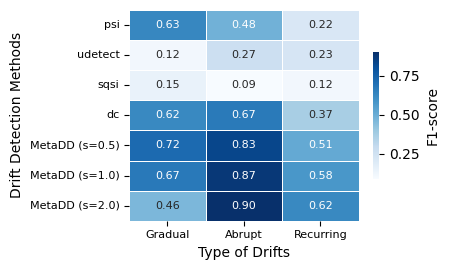

In [32]:
heatmap(df_drifts, 1.5, .4)

In [33]:
df_drifts.T

,psi,udetect,sqsi,dc,MetaDD (s=0.5),MetaDD (s=1.0),MetaDD (s=2.0)
Gradual,0.629096,0.116780,0.150685,0.622288,0.718228,0.673685,0.463671
Abrupt,0.484682,0.270781,0.092824,0.669443,0.832699,0.873239,0.899068
Recurring,0.217837,0.231356,0.116788,0.371341,0.512231,0.579049,0.623674


In [34]:
friedman_test_2(df_drifts.T, 0.05, True)

Friedman Test (Iman & Davenport correction)
  N (groups)  : 7
  k (methods) : 3
  χ²_F        : 13.5714  (p = 0.0348)
  F_F         : 190.0000  (p = 0.0000)  [df1=2, df2=12]
  alpha       : 0.05

✅ Rejeita H0: há diferença significativa entre os métodos.


True

In [35]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# 1. Primeiro testa H0 global com Friedman
stat, p_value = friedmanchisquare(*[df_drifts.loc[row] for row in df_drifts.index])
print(f"Friedman p-value: {p_value:.4f}")

# 2. Só se H0 for rejeitada, aplica o post-hoc
if p_value < 0.05:
    print("✅ H0 rejeitada — aplicando post-hoc de Nemenyi...\n")
    posthoc = sp.posthoc_nemenyi_friedman(df_gradual.T)
    print(posthoc)
else:
    print("❌ H0 não rejeitada — post-hoc não aplicável.")

Friedman p-value: 0.0348
✅ H0 rejeitada — aplicando post-hoc de Nemenyi...

                     psi   udetect      sqsi        dc  MetaDD (s=0.5)  \
psi             1.000000  0.336190  0.146194  0.997553        0.999640   
udetect         0.336190  1.000000  0.999640  0.711269        0.146194   
sqsi            0.146194  0.999640  1.000000  0.437865        0.050343   
dc              0.997553  0.711269  0.437865  1.000000        0.958006   
MetaDD (s=0.5)  0.999640  0.146194  0.050343  0.958006        1.000000   
MetaDD (s=1.0)  1.000000  0.290208  0.120280  0.994880        0.999902   
MetaDD (s=2.0)  0.958006  0.913892  0.711269  0.999640        0.806857   

                MetaDD (s=1.0)  MetaDD (s=2.0)  
psi                   1.000000        0.958006  
udetect               0.290208        0.913892  
sqsi                  0.120280        0.711269  
dc                    0.994880        0.999640  
MetaDD (s=0.5)        0.999902        0.806857  
MetaDD (s=1.0)        1.000000       

In [36]:
import numpy as np
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

data = np.array(list(data_dic.values()))

# Friedman test
stat, p = friedmanchisquare(*data.T)
print(f"Friedman stat={stat:.4f}, p={p:.4f}")

# Nemenyi post-hoc
nemenyi = sp.posthoc_nemenyi_friedman(data)
print(nemenyi)

Friedman stat=68.8353, p=0.0000
          0         1             2         3         4             5  \
0  1.000000  0.185835  9.808882e-02  1.000000  0.461023  8.023625e-02   
1  0.185835  1.000000  9.999684e-01  0.170683  0.000263  3.976480e-06   
2  0.098089  0.999968  1.000000e+00  0.088803  0.000075  8.994234e-07   
3  1.000000  0.170683  8.880320e-02  1.000000  0.486791  8.880320e-02   
4  0.461023  0.000263  7.511347e-05  0.486791  1.000000  9.797092e-01   
5  0.080236  0.000004  8.994234e-07  0.088803  0.979709  1.000000e+00   
6  0.072352  0.000003  7.230631e-07  0.080236  0.974568  1.000000e+00   

              6  
0  7.235225e-02  
1  3.230062e-06  
2  7.230631e-07  
3  8.023625e-02  
4  9.745682e-01  
5  1.000000e+00  
6  1.000000e+00  


In [37]:
import numpy as np
from scipy.stats import studentized_range

def compute_cd(k, N, alpha=0.05):
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    return q_alpha * np.sqrt(k * (k + 1) / (6 * N))

ALPHA = 0.05
cd = compute_cd(k=data.shape[1], N=data.shape[0], alpha=ALPHA)
print("Critical distance (CD):", cd)

Critical distance (CD): 2.1230330588372373


In [38]:
df = col_filter(final_performances_df)
df["dataset"] = df["dataset"].replace(dataset_rename)
df["alert_col"] = df["alert_col"].replace(alert_col_rename)

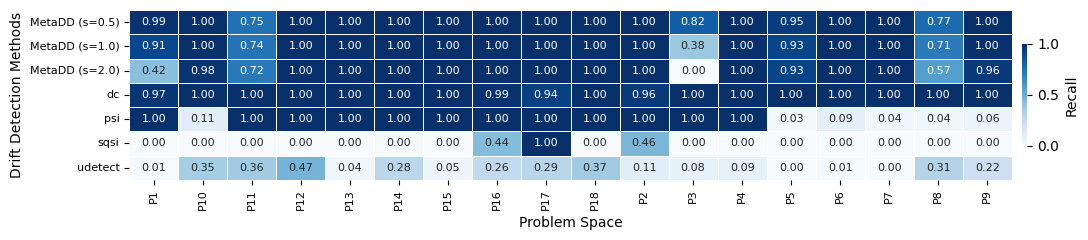

In [39]:
plot_heatmap(df, 'recall', 'Recall')

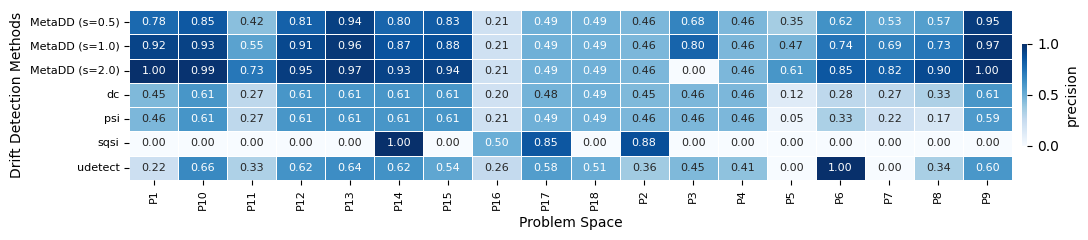

In [40]:
plot_heatmap(df, 'precision')

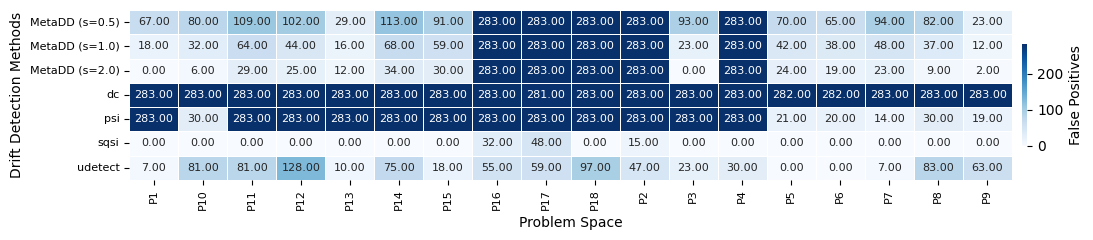

In [41]:
plot_heatmap(df, 'False Positives')

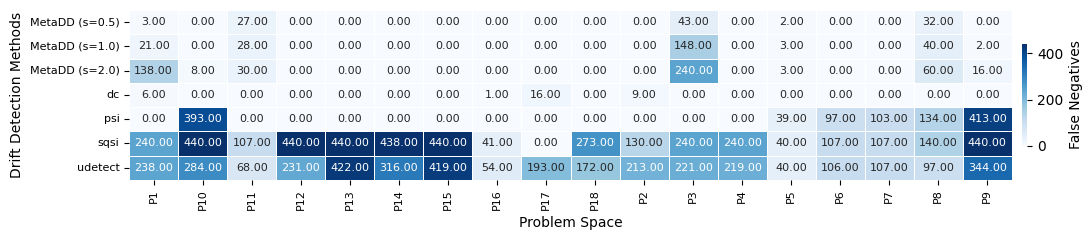

In [42]:
plot_heatmap(df, 'False Negatives')

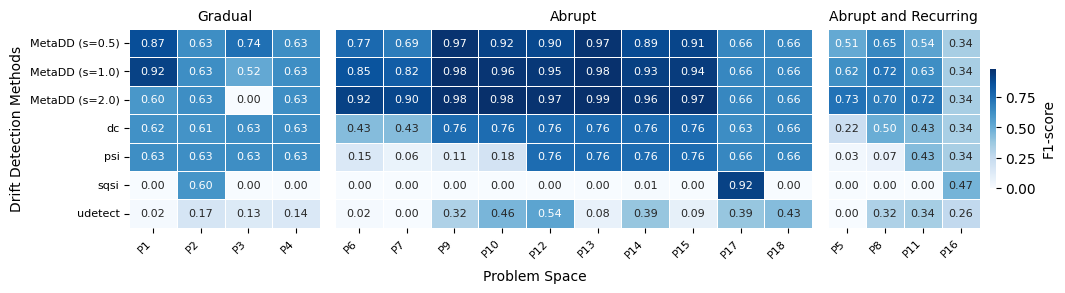

In [43]:
plot_heatmap_grouped(df, 'f1-score', 'F1-score')

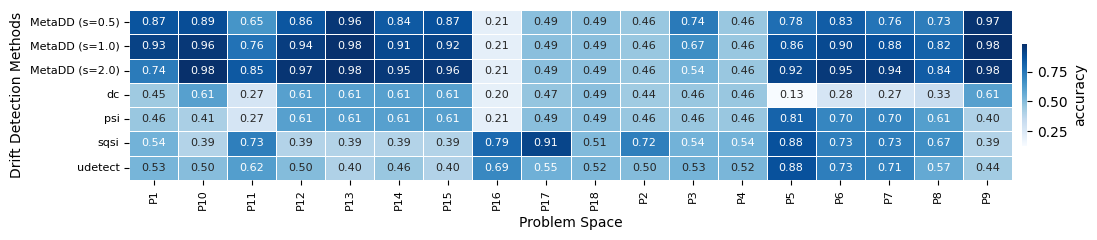

In [44]:
plot_heatmap(df, 'accuracy')

# Friedman test

In [45]:
def evaluate_classifiers_friedman(data: pd.DataFrame, metric: str):
    num_datasets, num_classifiers = data.shape

    # Compute ranks for each dataset
    ranks = []
    for i in range(num_datasets):
        ranks.append(rankdata(-np.array(data.iloc[i])))

    # Calculate average ranks
    avg_ranks = np.mean(ranks, axis=0)

    # Perform the Friedman test
    chi2, _ = friedmanchisquare(*ranks)
    df_between = num_classifiers - 1
    df_within = (num_classifiers - 1) * (num_datasets - 1)
    f_value = (num_datasets - 1) * chi2 / df_within
    p_value = 1 - f.cdf(f_value, df_between, df_within)

    # Create list of dictionaries with classifier ranks
    return [{
            "Classifier": classifier,
            "Ranking Position": pos + 1,
            "Average Rank": rank,
            "Metric": metric,
            "chi2": chi2,
            "p_value": p_value,
        } for pos, (classifier, rank) in enumerate(sorted(zip(data.columns, avg_ranks), key=lambda x: x[1]))
    ]

def evaluate_all_metrics(final_performances_df: pd.DataFrame):
    metrics = ["precision", "recall", "f1-score"]
    cols_to_drop = ["target_alert"] #, "mtl_alert_kappa_s=1.5", "mtl_alert_kappa_s=1", "mtl_alert_kappa_s=0.5"]
    results = []
    clf_results = final_performances_df.copy()
    clf_results = final_performances_df[final_performances_df["dataset"] != 'gradual_friedman']

    for metric in metrics:
        results_pivot = clf_results.pivot(index="dataset", values=metric, columns='alert_col').drop(cols_to_drop, axis=1)
        for col in results_pivot.columns:
            results_pivot = results_pivot.rename(columns={col: col.replace("dc_drift_flag", "domain_classifier").replace("_drift_flag", "").replace("_alert_kappa", "")})

        results = [*results, *evaluate_classifiers_friedman(results_pivot, metric)]
    return pd.DataFrame(results)

In [46]:
friedman_results = evaluate_all_metrics(final_performances_df)
friedman_results.head(10)

,Classifier,Ranking Position,Average Rank,Metric,chi2,p_value
0,mtl_s=2,1,2.850,precision,18.897393,0.020073
1,mtl_s=1.5,2,3.000,precision,18.897393,0.020073
2,mtl_s=1,3,3.700,precision,18.897393,0.020073
3,mtl_s=0.5,4,4.350,precision,18.897393,0.020073
4,u_detect,5,5.300,precision,18.897393,0.020073
5,psi,6,5.700,precision,18.897393,0.020073
6,domain_classifier,7,6.050,precision,18.897393,0.020073
7,sqsi,8,6.675,precision,18.897393,0.020073
8,omv_pth,9,7.375,precision,18.897393,0.020073
9,mtl_s=0.5,1,3.100,recall,7.663263,0.471185


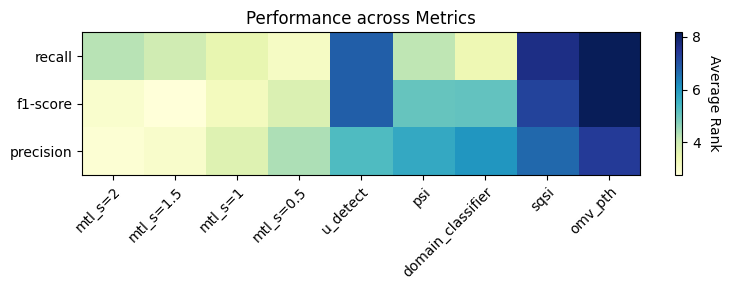

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ranking_heatmap(results: list):
    # Prepare data
    metrics = list(set(result["Metric"] for result in results))
    classifiers = list(set(result["Classifier"] for result in results))
    num_classifiers = len(classifiers)
    num_metrics = len(metrics)

    # Sort classifiers based on precision values
    sorted_classifiers = sorted(classifiers, key=lambda c: next((result["Average Rank"] for result in results if result["Classifier"] == c and result["Metric"] == "precision"), 0))

    # Create a data array for heatmap
    data = np.zeros((num_metrics, num_classifiers))
    for result in results:
        classifier_idx = sorted_classifiers.index(result["Classifier"])
        metric_idx = metrics.index(result["Metric"])
        data[metric_idx, classifier_idx] = result["Average Rank"]

    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 3))
    heatmap = ax.imshow(data, cmap='YlGnBu', aspect='auto')

    # Set x-axis and y-axis labels
    ax.set_xticks(np.arange(num_classifiers))
    ax.set_yticks(np.arange(num_metrics))
    ax.set_xticklabels(sorted_classifiers, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(metrics)

    # Add colorbar
    cbar = ax.figure.colorbar(heatmap, ax=ax)
    cbar.ax.set_ylabel('Average Rank', rotation=-90, va="bottom")

    # Set title and adjust layout
    ax.set_title("Performance across Metrics")
    plt.tight_layout()

    # Display the heatmap
    plt.show()

plot_ranking_heatmap(friedman_results.to_dict(orient='records'))